# NLP from scratch: character-level RNN

Companion notebook for the [PyTorch character-level RNN tutorial](https://docs.pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html).

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

import torch

device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device('cpu')
)
print(f'Using {device} device')

Using mps device


## Download the tutorial datasets

The official archive contains a top-level data directory. The code stores the ZIP in torch/data and extracts it into torch/, producing torch/data/names/*.txt and torch/data/eng-fra.txt. It is idempotent: later runs reuse the downloaded archive and skip extraction when all expected files are present.

In [2]:
DATA_URL = 'https://download.pytorch.org/tutorial/data.zip'

working_dir = Path.cwd().resolve()
torch_dir = working_dir if working_dir.name == 'torch' else working_dir / 'torch'
data_dir = torch_dir / 'data'
archive_path = data_dir / 'pytorch_tutorial_data.zip'
names_dir = data_dir / 'names'
translation_path = data_dir / 'eng-fra.txt'
data_dir.mkdir(parents=True, exist_ok=True)

if archive_path.is_file():
    print(f'Reusing archive: {archive_path}')
else:
    partial_path = archive_path.with_suffix('.zip.part')
    print(f'Downloading {DATA_URL}')
    urlretrieve(DATA_URL, partial_path)
    partial_path.replace(archive_path)
    print(f'Downloaded: {archive_path}')

name_files = sorted(names_dir.glob('*.txt')) if names_dir.is_dir() else []
data_is_ready = len(name_files) == 18 and translation_path.is_file()

if data_is_ready:
    print(f'Reusing extracted data: {data_dir}')
else:
    with ZipFile(archive_path) as archive:
        corrupt_member = archive.testzip()
        if corrupt_member is not None:
            raise RuntimeError(f'Corrupt ZIP member: {corrupt_member}')
        archive.extractall(torch_dir)
    print(f'Extracted data into: {data_dir}')

name_files = sorted(names_dir.glob('*.txt'))
if len(name_files) != 18 or not translation_path.is_file():
    raise RuntimeError('The tutorial dataset did not extract as expected.')

print(f'Archive size: {archive_path.stat().st_size / 1_000_000:.2f} MB')
print(f'Language files: {len(name_files)}')
print(f'Translation file: {translation_path.name}')

Downloaded: /Users/rad/dev/minor/ml/llmsfs/torch/data/pytorch_tutorial_data.zip
Extracted data into: /Users/rad/dev/minor/ml/llmsfs/torch/data
Archive size: 2.88 MB
Language files: 18
Translation file: eng-fra.txt


In [3]:
language_names = [path.stem for path in name_files]
sample_path = names_dir / 'Italian.txt'
sample_names = sample_path.read_text(encoding='utf-8').splitlines()[:5]

print('Languages:')
print(', '.join(language_names))
print(f'\nFirst five names from {sample_path.name}:')
print(sample_names)

Languages:
Arabic, Chinese, Czech, Dutch, English, French, German, Greek, Irish, Italian, Japanese, Korean, Polish, Portuguese, Russian, Scottish, Spanish, Vietnamese

First five names from Italian.txt:
['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


In [6]:
# Convert unicode strings to ASCII and only allow a small subset of characters
import string 
import unicodedata

# Use "_" to represent any unrepresented/out of vocabulary character
allowed_characters = string.ascii_letters + " .,;'" + "_"
n_letters = len(allowed_characters)

def unicode_to_ascii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

In [7]:
print (f"converting 'Ślusàrski' to {unicode_to_ascii('Ślusàrski')}")

converting 'Ślusàrski' to Slusarski


In [13]:
# Find letter index from all_letters, e.g "a" = 0
def letter_to_index(letter):
    if letter not in allowed_characters:
        return allowed_characters.find("_")
    else:
        return allowed_characters.find(letter)

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def line_to_tensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letter_to_index(letter)] = 1
    return tensor

In [14]:
print (f"The letter 'a' becomes {line_to_tensor('a')}") #notice that the first position in the tensor = 1
print (f"The name 'Ahn' becomes {line_to_tensor('Ahn')}") #notice 'A' sets the 27th index to 1

The letter 'a' becomes tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]]])
The name 'Ahn' becomes tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [26]:
from io import open
import glob
import os
import time

import torch
from torch.utils.data import Dataset


class NamesDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.load_time = time.localtime
        labels_set = set() # set of all classes

        self.data = []
        self.data_tensors = []
        self.labels = []
        self.labels_tensors = []

        text_files = glob.glob(os.path.join(data_dir, "*.txt"))
        print(text_files)
        for filename in text_files:
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(line_to_tensor(name))
                self.labels.append(label)


        # cache the tensor representations of the labels
        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor([self.labels_uniq.index(self.labels[idx])], dtype=torch.long)
            self.labels_tensors.append(temp_tensor)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        data_item = self.data[index]
        data_label = self.labels[index]
        data_tensor = self.data_tensors[index]
        label_tensor = self.labels_tensors[index]
        return label_tensor, data_tensor, data_label, data_item

In [27]:
alldata = NamesDataset(names_dir)
print(f"loaded {len(alldata)} items of data")
print(f"example = {alldata[0]}")

['/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Czech.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/German.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Arabic.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Japanese.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Chinese.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Vietnamese.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Russian.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/French.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Irish.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/English.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Spanish.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Greek.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Italian.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Portuguese.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Scottish.txt', '/Users/rad/dev/minor/ml/llmsfs/torch/data/names/Dutch.

In [29]:
train_set, test_set = torch.utils.data.random_split(alldata, [.85, .15], generator=torch.Generator(device="cpu").manual_seed(2024))

print(f"train examples = {len(train_set)}, validation examples = {len(test_set)}")

train examples = 17063, validation examples = 3011


In [30]:
import torch.nn as nn
import torch.nn.functional as F


class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        rnn_out, hidden = self.rnn(line_tensor)
        output = self.h2o(hidden[0])
        output = self.softmax(output)
        return output


In [31]:
n_hidden = 128
rnn = CharRNN(n_letters, n_hidden, len(alldata.labels_uniq))
print(rnn)

CharRNN(
  (rnn): RNN(58, 128)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [33]:
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

input = line_to_tensor('Albert')
output = rnn(input)
print(output)
print(label_from_output(output, alldata.labels_uniq))

tensor([[-2.9632, -2.8526, -3.0227, -3.0832, -2.7690, -2.9812, -2.8596, -2.9709,
         -2.8292, -2.8461, -2.7724, -3.0428, -2.8578, -2.9394, -2.8924, -2.7912,
         -2.8516, -2.7808]], grad_fn=<LogSoftmaxBackward0>)
('Korean', 4)


In [37]:
import random
import numpy as np


def train(rnn, training_data, n_epoch = 10, n_batch_size = 64, report_every = 50, learning_rate = 0.2, criterion = nn.NLLLoss()):
    current_loss = 0
    all_losses = []
    rnn.train()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

    print(f"training on data set with n = {len(training_data)}")

    for iter in range(1, n_epoch + 1):
        rnn.zero_grad()

        # create some minibatches 
        # we cannot use dataloaders because each of our names is a different length
        batches = list(range(len(training_data)))
        random.shuffle(batches)
        batches = np.array_split(batches, len(batches) // n_batch_size)


        for idx, batch in enumerate(batches):
            batch_loss = 0
            for i in batch:
                (label_tensor, text_tensor, label, text) = training_data[i]
                output = rnn.forward(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

            batch_loss.backward()
            nn.utils.clip_grad_norm_(rnn.parameters(), 3)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / len(batch)

        all_losses.append(current_loss / len(batches))
        if iter % report_every == 0:
            print(f"{iter} ({iter / n_epoch:.0%}): \t average batch loss = {all_losses[-1]}")
        current_loss = 0

    return all_losses



In [41]:
start = time.time()
all_losses = train(rnn, train_set, n_epoch=47, learning_rate=0.10, report_every=5)
end = time.time()
print(f"training took {end-start}s")

training on data set with n = 17063
5 (11%): 	 average batch loss = 0.28019296159076856
10 (21%): 	 average batch loss = 0.25601673250756146
15 (32%): 	 average batch loss = 0.22301948153348655
20 (43%): 	 average batch loss = 0.21248858034149665
25 (53%): 	 average batch loss = 0.20113276833007968
30 (64%): 	 average batch loss = 0.1891922210629204
35 (74%): 	 average batch loss = 0.18901418774044534
40 (85%): 	 average batch loss = 0.1860467727994681
45 (96%): 	 average batch loss = 0.18256387786068207
training took 156.92328119277954s


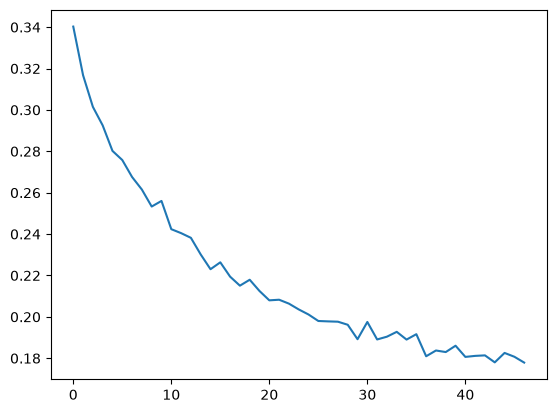

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)
plt.show()

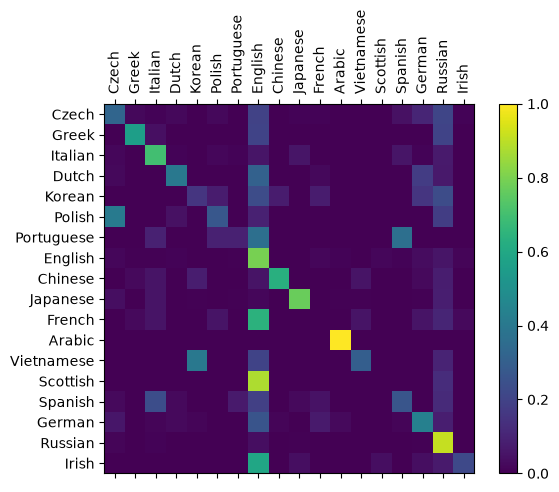

In [43]:
def evaluate(rnn, testing_data, classes):
    confusion = torch.zeros(len(classes), len(classes))

    rnn.eval() #set to eval mode
    with torch.no_grad(): # do not record the gradients during eval phase
        for i in range(len(testing_data)):
            (label_tensor, text_tensor, label, text) = testing_data[i]
            output = rnn(text_tensor)
            guess, guess_i = label_from_output(output, classes)
            label_i = classes.index(label)
            confusion[label_i][guess_i] += 1

    # Normalize by dividing every row by its sum
    for i in range(len(classes)):
        denom = confusion[i].sum()
        if denom > 0:
            confusion[i] = confusion[i] / denom

    # Set up plot
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.cpu().numpy()) #numpy uses cpu here so we need to use a cpu version
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticks(np.arange(len(classes)), labels=classes, rotation=90)
    ax.set_yticks(np.arange(len(classes)), labels=classes)

    # Force label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # sphinx_gallery_thumbnail_number = 2
    plt.show()



evaluate(rnn, test_set, classes=alldata.labels_uniq)